In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    Input
)
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12,6)

In [2]:
SUPPORTED_STOCKS = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "NVDA"
]

In [3]:
def load_stock_data(ticker):

    print("\n" + "="*70)
    print(f"LSTM MODEL : {ticker}")
    print("="*70)

    DATA_PATH = f"../data/{ticker}/processed/processed_stock_data.csv"

    MODEL_DIR = f"../models/{ticker}"
    REPORT_DIR = f"../reports/{ticker}"

    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(REPORT_DIR, exist_ok=True)

    stock = pd.read_csv(DATA_PATH)

    stock["Date"] = pd.to_datetime(stock["Date"])

    print("Dataset Shape :", stock.shape)

    return stock, MODEL_DIR, REPORT_DIR

In [4]:
FEATURES = [
    "Close",
    "Volume",
    "SMA20",
    "SMA50",
    "EMA20",
    "RSI",
    "MACD",
    "Volatility"
]

TARGET = "Close"

In [5]:
def scale_dataset(stock):

    X = stock[FEATURES].values
    y = stock[[TARGET]].values

    feature_scaler = MinMaxScaler()
    target_scaler = MinMaxScaler()

    X_scaled = feature_scaler.fit_transform(X)
    y_scaled = target_scaler.fit_transform(y)

    return (
        X_scaled,
        y_scaled,
        feature_scaler,
        target_scaler
    )

In [6]:
def create_sequences(X, y, sequence_length=60):

    X_seq = []
    y_seq = []

    for i in range(sequence_length, len(X)):

        X_seq.append(
            X[i-sequence_length:i]
        )

        y_seq.append(
            y[i]
        )

    return np.array(X_seq), np.array(y_seq)

In [7]:
def split_dataset(X_seq, y_seq):

    train_end = int(len(X_seq) * 0.70)
    val_end = int(len(X_seq) * 0.85)

    X_train = X_seq[:train_end]
    y_train = y_seq[:train_end]

    X_val = X_seq[train_end:val_end]
    y_val = y_seq[train_end:val_end]

    X_test = X_seq[val_end:]
    y_test = y_seq[val_end:]

    print("Training Samples :", len(X_train))
    print("Validation Samples :", len(X_val))
    print("Testing Samples :", len(X_test))

    return X_train, X_val, X_test, y_train, y_val, y_test

In [8]:
def build_lstm_model(input_shape):

    model = Sequential([

        Input(shape=input_shape),

        LSTM(128, return_sequences=True),

        Dropout(0.2),

        LSTM(64),

        Dropout(0.2),

        Dense(32, activation="relu"),

        Dense(1)

    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model

In [9]:
def train_lstm_model(model,
                     X_train,
                     y_train,
                     X_val,
                     y_val):

    early_stop = EarlyStopping(

        monitor="val_loss",

        patience=10,

        restore_best_weights=True
    )

    history = model.fit(

        X_train,

        y_train,

        validation_data=(X_val, y_val),

        epochs=100,

        batch_size=32,

        callbacks=[early_stop],

        verbose=1
    )

    return history

In [10]:
def evaluate_model(model,
                   X_test,
                   y_test,
                   target_scaler):

    prediction = model.predict(X_test)

    prediction = target_scaler.inverse_transform(prediction)

    actual = target_scaler.inverse_transform(y_test)

    mae = mean_absolute_error(actual, prediction)

    rmse = np.sqrt(
        mean_squared_error(actual, prediction)
    )

    r2 = r2_score(actual, prediction)

    print("\nModel Performance")
    print("-"*40)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    return actual, prediction

In [11]:
def plot_prediction(actual,
                    prediction,
                    ticker):

    plt.figure(figsize=(14,6))

    plt.plot(
        actual,
        label="Actual"
    )

    plt.plot(
        prediction,
        label="Predicted"
    )

    plt.title(f"{ticker} LSTM Prediction")

    plt.xlabel("Time")

    plt.ylabel("Closing Price")

    plt.legend()

    plt.grid(True)

    plt.show()

In [12]:
def save_model(model,
               feature_scaler,
               target_scaler,
               MODEL_DIR):

    model.save(
        os.path.join(
            MODEL_DIR,
            "lstm_model.keras"
        )
    )

    joblib.dump(
        feature_scaler,
        os.path.join(
            MODEL_DIR,
            "feature_scaler.pkl"
        )
    )

    joblib.dump(
        target_scaler,
        os.path.join(
            MODEL_DIR,
            "target_scaler.pkl"
        )
    )

    print("Model Saved Successfully")


LSTM MODEL : AAPL
Dataset Shape : (845, 80)
Training Samples : 549
Validation Samples : 118
Testing Samples : 118
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 192ms/step - loss: 0.0135 - mae: 0.0888 - val_loss: 0.0156 - val_mae: 0.1155
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 0.0047 - mae: 0.0538 - val_loss: 0.0069 - val_mae: 0.0732
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - loss: 0.0028 - mae: 0.0410 - val_loss: 0.0074 - val_mae: 0.0763
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0029 - mae: 0.0412 - val_loss: 0.0037 - val_mae: 0.0510
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0027 - mae: 0.0401 - val_loss: 0.0020 - val_mae: 0.0354
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0023 - mae: 0.0366 - val_loss: 0.0017 - val_mae: 0.0324
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.0024 - mae: 0.0372 - val_loss: 0.0032 - val_mae: 0.0462
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step -

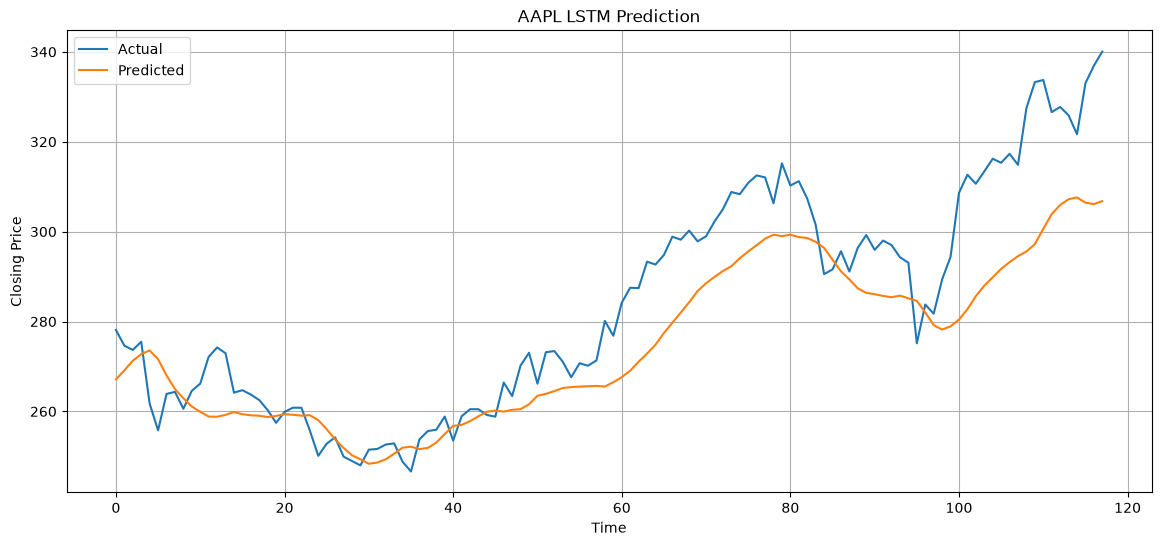

Model Saved Successfully

LSTM MODEL : MSFT
Dataset Shape : (845, 80)
Training Samples : 549
Validation Samples : 118
Testing Samples : 118
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - loss: 0.0688 - mae: 0.1913 - val_loss: 0.0107 - val_mae: 0.0919
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0101 - mae: 0.0807 - val_loss: 0.0045 - val_mae: 0.0517
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0069 - mae: 0.0649 - val_loss: 0.0043 - val_mae: 0.0569
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - loss: 0.0053 - mae: 0.0572 - val_loss: 0.0055 - val_mae: 0.0663
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - loss: 0.0043 - mae: 0.0511 - val_loss: 0.0044 - val_mae: 0.0575
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - loss: 0.0044 - mae: 0.0514 - val_loss: 0.0137 - val_mae: 0.1091
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - loss: 0.0040 - mae: 0.0498 - val_loss: 0.0083 - val_mae: 0.0829
Epoch 8/100
18/18 ━━━━━━━━

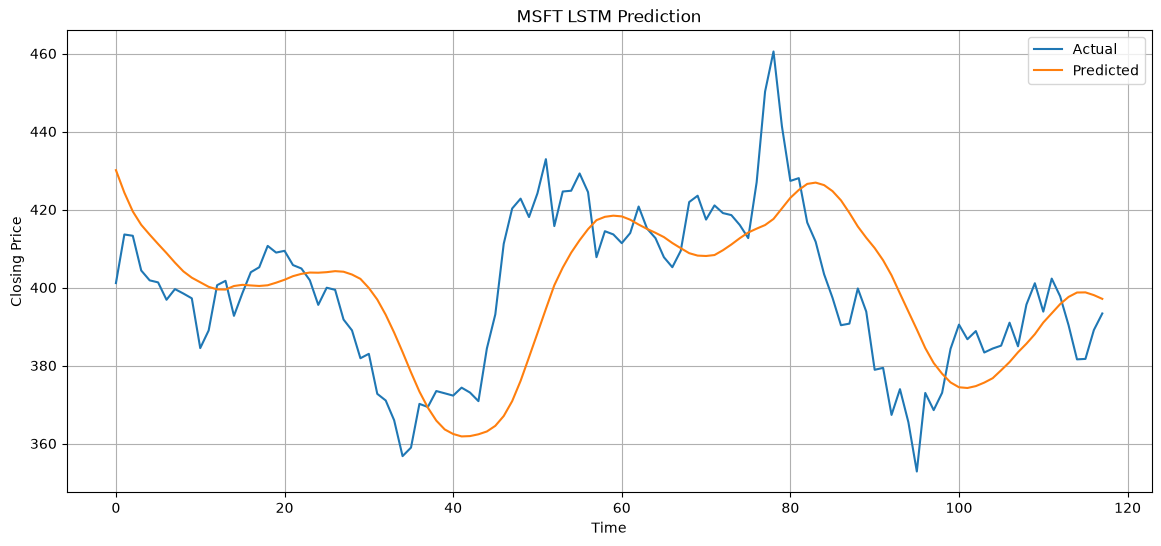

Model Saved Successfully

LSTM MODEL : GOOGL
Dataset Shape : (845, 80)
Training Samples : 549
Validation Samples : 118
Testing Samples : 118
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 173ms/step - loss: 0.0091 - mae: 0.0712 - val_loss: 0.0749 - val_mae: 0.2644
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - loss: 0.0021 - mae: 0.0370 - val_loss: 0.0057 - val_mae: 0.0666
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - loss: 0.0015 - mae: 0.0307 - val_loss: 0.0234 - val_mae: 0.1457
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 9.5784e-04 - mae: 0.0245 - val_loss: 0.0102 - val_mae: 0.0919
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 8.9271e-04 - mae: 0.0225 - val_loss: 0.0085 - val_mae: 0.0819
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 7.5031e-04 - mae: 0.0213 - val_loss: 0.0092 - val_mae: 0.0844
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 7.1325e-04 - mae: 0.0206 - val_loss: 0.0103 - val_mae: 0.0914
Epoch 8/1

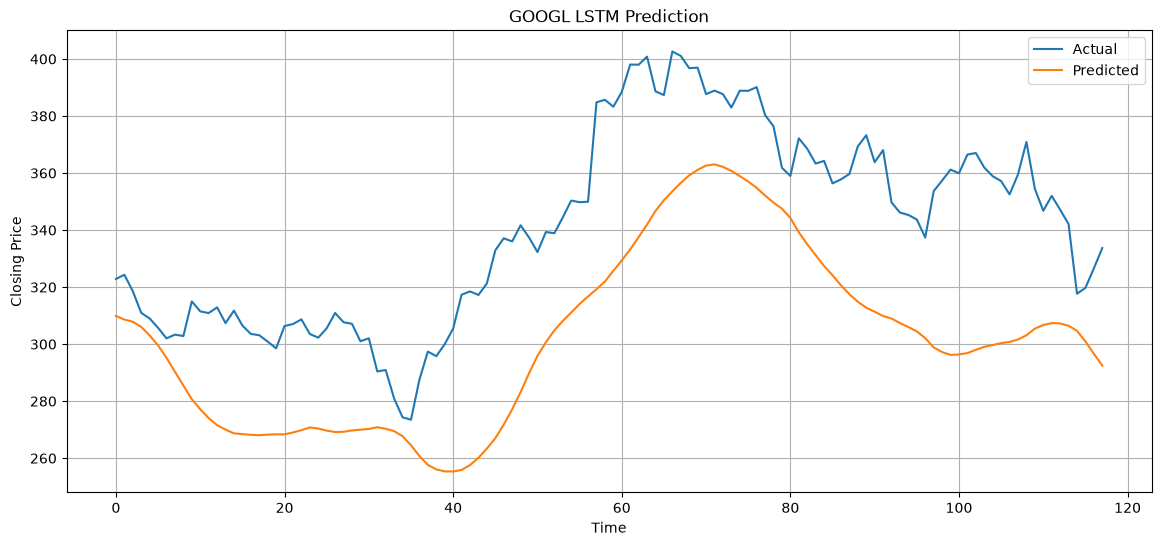

Model Saved Successfully

LSTM MODEL : AMZN
Dataset Shape : (845, 80)
Training Samples : 549
Validation Samples : 118
Testing Samples : 118
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - loss: 0.0483 - mae: 0.1561 - val_loss: 0.0023 - val_mae: 0.0360
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0096 - mae: 0.0736 - val_loss: 0.0028 - val_mae: 0.0411
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0045 - mae: 0.0524 - val_loss: 0.0049 - val_mae: 0.0566
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.0047 - mae: 0.0510 - val_loss: 0.0074 - val_mae: 0.0737
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.0042 - mae: 0.0498 - val_loss: 0.0055 - val_mae: 0.0618
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0037 - mae: 0.0471 - val_loss: 0.0033 - val_mae: 0.0433
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - loss: 0.0036 - mae: 0.0450 - val_loss: 0.0057 - val_mae: 0.0635
Epoch 8/100
18/18 ━━━━━━━━━━━━━

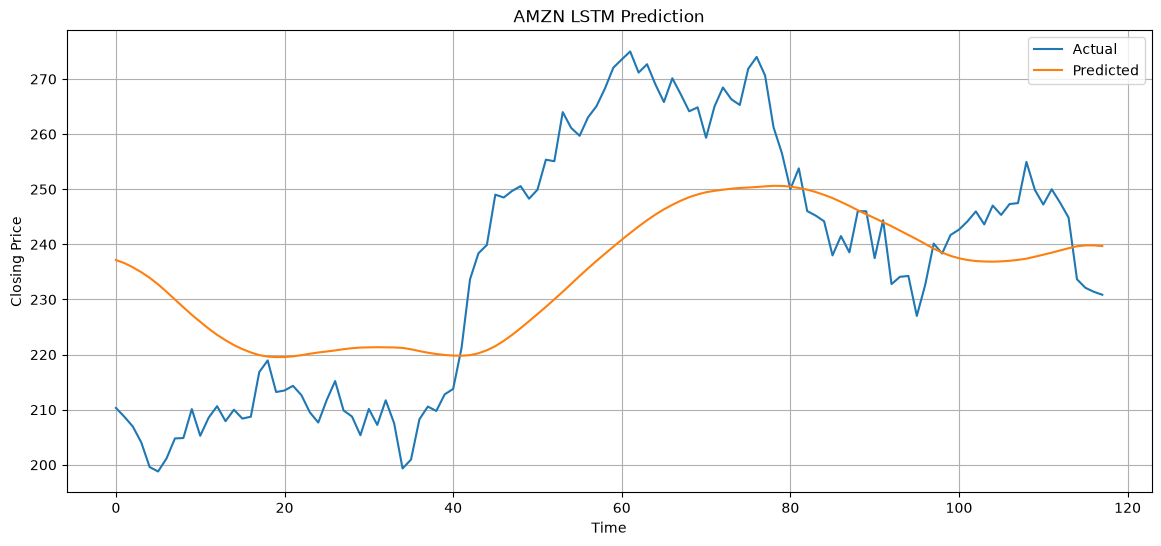

Model Saved Successfully

LSTM MODEL : NVDA
Dataset Shape : (845, 80)
Training Samples : 549
Validation Samples : 118
Testing Samples : 118
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 141ms/step - loss: 0.0248 - mae: 0.1147 - val_loss: 0.0148 - val_mae: 0.1174
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0053 - mae: 0.0537 - val_loss: 0.0056 - val_mae: 0.0659
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0033 - mae: 0.0445 - val_loss: 0.0041 - val_mae: 0.0546
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.0028 - mae: 0.0397 - val_loss: 0.0116 - val_mae: 0.1016
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0026 - mae: 0.0377 - val_loss: 0.0037 - val_mae: 0.0510
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0029 - mae: 0.0403 - val_loss: 0.0092 - val_mae: 0.0886
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0021 - mae: 0.0339 - val_loss: 0.0194 - val_mae: 0.1349
Epoch 8/100
18/18 ━━━━━━━━━━━━━━

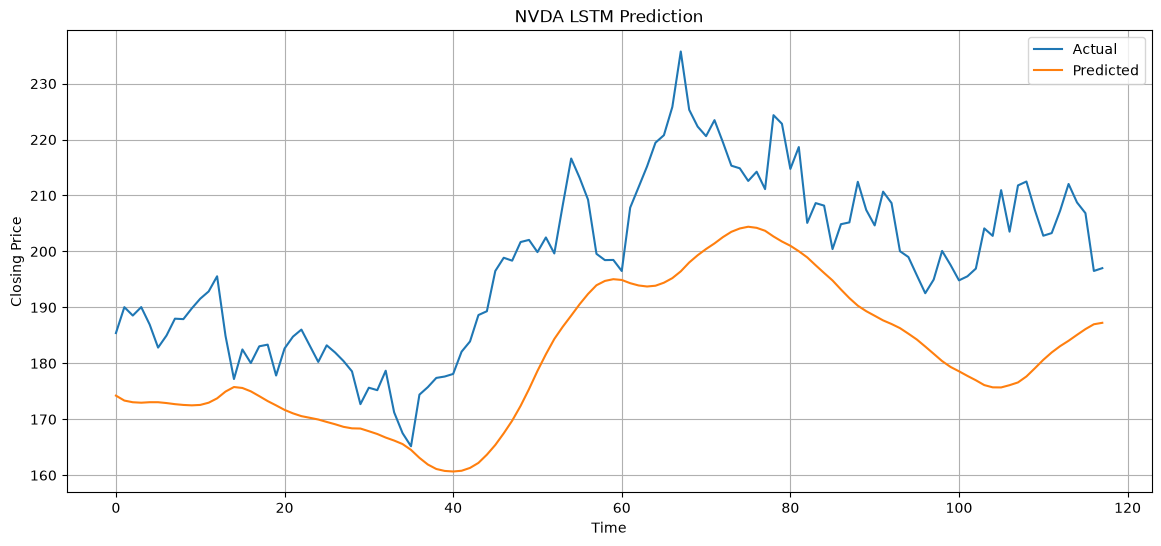

Model Saved Successfully

LAB 7 COMPLETED SUCCESSFULLY


In [13]:
for ticker in SUPPORTED_STOCKS:

    stock, MODEL_DIR, REPORT_DIR = load_stock_data(ticker)

    X_scaled, y_scaled, feature_scaler, target_scaler = scale_dataset(stock)

    X_seq, y_seq = create_sequences(
        X_scaled,
        y_scaled
    )

    (
        X_train,
        X_val,
        X_test,
        y_train,
        y_val,
        y_test
    ) = split_dataset(
        X_seq,
        y_seq
    )

    model = build_lstm_model(
        (
            X_train.shape[1],
            X_train.shape[2]
        )
    )

    history = train_lstm_model(
        model,
        X_train,
        y_train,
        X_val,
        y_val
    )

    actual, prediction = evaluate_model(
        model,
        X_test,
        y_test,
        target_scaler
    )

    plot_prediction(
        actual,
        prediction,
        ticker
    )

    save_model(
        model,
        feature_scaler,
        target_scaler,
        MODEL_DIR
    )

print("\n" + "="*70)
print("LAB 7 COMPLETED SUCCESSFULLY")
print("="*70)